In [ ]:
# Core Deep Learning
!pip install -q torch torchvision

# DICOM handling
!pip install -q pydicom

# Image processing and transformations
!pip install -q pillow opencv-python

# Data handling and progress visualization
!pip install -q numpy matplotlib tqdm scikit-learn

# Optional: for model summary visualization
!pip install -q torchsummary


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.8 MB/s eta 0:00:00


In [ ]:
# -------------------------------
# Core PyTorch and Vision Libraries
# -------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split

# -------------------------------
# Optimization & Learning Rate Schedulers
# -------------------------------
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# -------------------------------
# Metrics & Evaluation
# -------------------------------
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -------------------------------
# Image and Medical Data Handling
# -------------------------------
import numpy as np
import cv2
import os
import pydicom
from PIL import Image

# -------------------------------
# Visualization and Progress Display
# -------------------------------
import matplotlib.pyplot as plt
from tqdm import tqdm

# -------------------------------
# Model Summary (for overview)
# -------------------------------
from torchsummary import summary


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# -------------------------------
# Dataset Root Directory
# -------------------------------
data_root = '/content/drive/MyDrive/Major project Final models/major project dataset'

# Check available folders or patient cases in alphabetical order
print("Classes / Patient Folders Found :")
folders = sorted(os.listdir(data_root))
print(folders)


Classes / Patient Folders Found :
['patient 1', 'patient 2', 'patient 3', 'patient 4', 'patient 5', 'patient 6', 'patient 7']


In [ ]:
# -------------------------------
# Load DICOM Images, Compute SUVmax, Assign Labels & Save CSV
# -------------------------------
import os
import pandas as pd
import pydicom
import numpy as np

# Define dataset root and output CSV path
data_root = '/content/drive/MyDrive/Major project Final models/major project dataset'
output_csv = os.path.join(data_root, 'suv_values_with_labels.csv')

# -------------------------------
# Helper Function: Compute SUVmax
# -------------------------------
def calculate_suv(dcm, body_weight_kg=70.0):
    """Compute SUVmax from PET DICOM with proper unit handling."""
    try:
        pixel_array = dcm.pixel_array.astype(np.float32)
        slope = float(getattr(dcm, "RescaleSlope", 1.0))
        intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
        activity = pixel_array * slope + intercept  # raw activity

        # Use SUVConversionFactor if present
        if hasattr(dcm, 'SUVConversionFactor'):
            suv_array = activity * float(dcm.SUVConversionFactor)
            return np.max(suv_array)

        # Otherwise compute SUV manually
        if hasattr(dcm, "RadiopharmaceuticalInformationSequence"):
            rph = dcm.RadiopharmaceuticalInformationSequence[0]
            injected_dose_Bq = float(getattr(rph, "RadionuclideTotalDose", 370e6))
        else:
            injected_dose_Bq = 370e6  # fallback 370 MBq

        # Convert injected dose to kBq
        injected_dose_kBq = injected_dose_Bq / 1000.0
        body_weight_g = body_weight_kg * 1000.0
        activity_kBq_per_ml = activity / 1000.0
        suv_array = activity_kBq_per_ml / (injected_dose_kBq / body_weight_g)

        return np.max(suv_array)

    except Exception as e:
        print(f"⚠️ Error in file: {getattr(dcm, 'filename', 'Unknown')} | {e}")
        return 0.0

# -------------------------------
# Iterate through DICOMs and collect SUVmax
# -------------------------------
dicom_paths = []
suv_values = []

for patient in sorted(os.listdir(data_root)):
    patient_path = os.path.join(data_root, patient)
    if os.path.isdir(patient_path):
        for fname in os.listdir(patient_path):
            if fname.endswith('.dcm'):
                fpath = os.path.join(patient_path, fname)
                try:
                    dcm = pydicom.dcmread(fpath)
                    suv_max = calculate_suv(dcm)
                    dicom_paths.append(fpath)
                    suv_values.append(suv_max)
                except Exception as e:
                    print(f"Error reading {fpath}: {e}")

# -------------------------------
# Set Fixed SUV Threshold
# -------------------------------
threshold = 2.5
print(f"\n📊 Fixed SUV Threshold = {threshold}")

# Assign labels and print each DICOM info
labels = []
print("\nDICOM Path | SUVmax | Assigned Label")
for path, suv in zip(dicom_paths, suv_values):
    label = 1 if suv > threshold else 0  # 1 = Tumor, 0 = Fibrosis
    labels.append(label)
    print(f"{os.path.basename(path)} | {suv:.3f} | {'Tumor' if label==1 else 'Fibrosis'}")

# -------------------------------
# Create and Save DataFrame
# -------------------------------
df = pd.DataFrame({
    'dicom_path': dicom_paths,
    'SUVmax': suv_values,
    'label': labels
})
df.to_csv(output_csv, index=False)
print(f"\n💾 CSV with labels saved successfully at: {output_csv}")

# -------------------------------
# Display Summary
# -------------------------------
print("\n✅ First few entries:")
print(df.head())

print("\n✅ Last few entries:")
print(df.tail())

print(f"\nTotal DICOM slices processed: {len(df)}")

# Check class balance
print("\n📈 Label Distribution:")
print(df['label'].value_counts().rename({0: 'Fibrosis (Low SUV)', 1: 'Tumor (High SUV)'}))



📊 Fixed SUV Threshold = 2.5

DICOM Path | SUVmax | Assigned Label
1-03.dcm | 1.628 | Fibrosis
1-04.dcm | 1.837 | Fibrosis
1-10.dcm | 2.124 | Fibrosis
1-06.dcm | 2.159 | Fibrosis
1-02.dcm | 2.030 | Fibrosis
1-01.dcm | 2.397 | Fibrosis
1-08.dcm | 1.905 | Fibrosis
1-05.dcm | 2.123 | Fibrosis
1-09.dcm | 2.067 | Fibrosis
1-07.dcm | 2.184 | Fibrosis
1-19.dcm | 1.474 | Fibrosis
1-15.dcm | 1.598 | Fibrosis
1-20.dcm | 1.366 | Fibrosis
1-24.dcm | 1.181 | Fibrosis
1-16.dcm | 1.948 | Fibrosis
1-17.dcm | 1.674 | Fibrosis
1-27.dcm | 0.922 | Fibrosis
1-21.dcm | 1.655 | Fibrosis
1-18.dcm | 1.699 | Fibrosis
1-13.dcm | 0.899 | Fibrosis
1-23.dcm | 1.373 | Fibrosis
1-12.dcm | 1.344 | Fibrosis
1-22.dcm | 1.553 | Fibrosis
1-14.dcm | 1.364 | Fibrosis
1-11.dcm | 1.953 | Fibrosis
1-25.dcm | 1.271 | Fibrosis
1-26.dcm | 1.152 | Fibrosis
1-29.dcm | 0.991 | Fibrosis
1-33.dcm | 2.841 | Tumor
1-35.dcm | 4.526 | Tumor
1-36.dcm | 4.595 | Tumor
1-37.dcm | 1.843 | Fibrosis
1-34.dcm | 3.082 | Tumor
1-32.dcm | 1.837 | Fi

In [ ]:
import os
from collections import defaultdict

# Dataset root directory
data_root = '/content/drive/MyDrive/Major project Final models/major project dataset'

# Get class/patient folder names
classes = sorted(os.listdir(data_root))

# Dictionary to store counts
class_counts = defaultdict(int)

# Count number of DICOM files in each folder
for class_name in classes:
    class_dir = os.path.join(data_root, class_name)
    if os.path.isdir(class_dir):
        dicom_files = [f for f in os.listdir(class_dir) if f.endswith('.dcm')]
        class_counts[class_name] = len(dicom_files)

# Print counts per class/patient
print("📂 DICOM Counts per Patient/Class:")
for cls, count in class_counts.items():
    print(f"{cls:25s} : {count} DICOM slices")


📂 DICOM Counts per Patient/Class:
.ipynb_checkpoints        : 0 DICOM slices
patient 1                 : 83 DICOM slices
patient 2                 : 83 DICOM slices
patient 3                 : 83 DICOM slices
patient 4                 : 83 DICOM slices
patient 5                 : 83 DICOM slices
patient 6                 : 83 DICOM slices
patient 7                 : 83 DICOM slices


In [ ]:
from torch.utils.data import Dataset
import torch
import pydicom
from PIL import Image
import numpy as np

class BreastPETDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        dcm_path = self.df.loc[idx, 'dicom_path']
        suv = self.df.loc[idx, 'SUVmax']
        label = self.df.loc[idx, 'label']

        # Load DICOM image
        dcm = pydicom.dcmread(dcm_path)
        img = dcm.pixel_array.astype(np.float32)

        # Clip extreme values for PET
        img = np.clip(img, 0, 20)

        # Normalize to [0,1]
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)

        # Convert to 3-channel RGB
        img = (img * 255).astype(np.uint8)
        img = Image.fromarray(img).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long), torch.tensor(suv, dtype=torch.float32)


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming 'df' contains columns: ['dicom_path', 'SUVmax', 'label']

# Stratified split to maintain class balance (e.g., 80% train, 20% validation)
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

# Display dataset sizes
print(f" Training samples: {len(train_df)}")
print(f" Validation samples: {len(val_df)}")

# Optional: check label distribution
print("\n Training label distribution:")
print(train_df['label'].value_counts())
print("\n Validation label distribution:")
print(val_df['label'].value_counts())


 Training samples: 464
 Validation samples: 117

 Training label distribution:
label
0    232
1    232
Name: count, dtype: int64

 Validation label distribution:
label
0    59
1    58
Name: count, dtype: int64


In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

# -------------------------------
# Define image transformations
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),   # augmentation
    transforms.RandomRotation(10),       # augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# -------------------------------
# Create Datasets
# -------------------------------
train_dataset = BreastPETDataset(train_df, transform=transform)
val_dataset = BreastPETDataset(val_df, transform=transform)

# -------------------------------
# Create DataLoaders
# -------------------------------
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------------
# Test a single batch
# -------------------------------
for images, labels, suvs in train_loader:
    print("Batch image tensor shape:", images.shape)  # [batch_size, 3, 224, 224]
    print("Batch label tensor shape:", labels.shape)  # [batch_size]
    print("Batch SUV tensor shape:", suvs.shape)      # [batch_size]
    print("Labels:", labels.tolist())
    print("SUV values:", suvs.tolist())
    break


Batch image tensor shape: torch.Size([4, 3, 224, 224])
Batch label tensor shape: torch.Size([4])
Batch SUV tensor shape: torch.Size([4])
Labels: [0, 1, 1, 0]
SUV values: [1259.4530029296875, 2828.412109375, 2521.66748046875, 1052.578125]


In [ ]:
!pip install torchinfo

import torch
import torch.nn as nn
from torchinfo import summary

# -------------------------------
# Basic Block (ResNet)
# -------------------------------
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)

# -------------------------------
# Custom ResNet9 Model
# -------------------------------
class CustomResNet9(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(CustomResNet9, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = BasicBlock(64, 128, stride=2)
        self.layer2 = BasicBlock(128, 256, stride=2)
        self.layer3 = BasicBlock(256, 512, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        out = self.conv1(x)      # [B, 64, 224, 224]
        out = self.layer1(out)   # [B, 128, 112, 112]
        out = self.layer2(out)   # [B, 256, 56, 56]
        out = self.layer3(out)   # [B, 512, 28, 28]
        out = self.pool(out)     # [B, 512, 1, 1]
        out = out.view(out.size(0), -1)
        return self.fc(out)

# -------------------------------
# Instantiate and test
# -------------------------------
model = CustomResNet9(in_channels=3, num_classes=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Print model summary
summary(model, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
CustomResNet9                            [1, 2]                    --
├─Sequential: 1-1                        [1, 64, 224, 224]         --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,728
│    └─BatchNorm2d: 2-2                  [1, 64, 224, 224]         128
│    └─ReLU: 2-3                         [1, 64, 224, 224]         --
├─BasicBlock: 1-2                        [1, 128, 112, 112]        --
│    └─Sequential: 2-4                   [1, 128, 112, 112]        --
│    │    └─Conv2d: 3-1                  [1, 128, 112, 112]        8,192
│    │    └─BatchNorm2d: 3-2             [1, 128, 112, 112]        256
│    └─Conv2d: 2-5                       [1, 128, 112, 112]        73,728
│    └─BatchNorm2d: 2-6                  [1, 128, 112, 112]        256
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,4

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.

    Args:
        alpha (float): Weighting factor for the rare class.
        gamma (float): Focusing parameter to reduce loss contribution from easy examples.
        reduction (str): 'mean', 'sum', or 'none' to reduce the final loss.
    """
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Compute standard cross-entropy loss per sample
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')  # [batch_size]

        # Compute probability of the true class
        pt = torch.exp(-ce_loss)  # pt = prob(correct class)

        # Apply focal weighting
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        # Reduce according to the chosen method
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [ ]:
import torch

# -------------------------------
# Loss function
# -------------------------------
# FocalLoss handles class imbalance in Fibrosis vs Tumor slices
criterion = FocalLoss(alpha=1.0, gamma=2.0, reduction='mean')

# -------------------------------
# Optimizer
# -------------------------------
# Adam optimizer with a small learning rate (good for medical images)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
from tqdm import tqdm

num_epochs = 10

for epoch in range(num_epochs):
    # ----- TRAINING -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, suvs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)      # ResNet9 only takes images
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    avg_train_loss = running_loss / len(train_loader)

    # ----- VALIDATION -----
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels, suvs in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    # ----- LOGGING -----
    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.4f}\n")


Epoch 1/10 - Validation: 100%|██████████| 30/30 [00:02<00:00, 13.58it/s]



Epoch 1/10 Summary:
Train Loss: 0.0768 | Train Acc: 0.8664
Val   Loss: 0.0740 | Val   Acc: 0.9402



Epoch 2/10 - Validation: 100%|██████████| 30/30 [00:02<00:00, 10.89it/s]



Epoch 2/10 Summary:
Train Loss: 0.0761 | Train Acc: 0.8685
Val   Loss: 0.1139 | Val   Acc: 0.9060



Epoch 3/10 - Validation: 100%|██████████| 30/30 [00:02<00:00, 10.17it/s]


...


Epoch 8/10 Summary:
Train Loss: 0.0560 | Train Acc: 0.9052
Val   Loss: 0.0747 | Val   Acc: 0.9316



Epoch 9/10 - Validation: 100%|██████████| 30/30 [00:00<00:00, 33.22it/s]



Epoch 9/10 Summary:
Train Loss: 0.0549 | Train Acc: 0.8966
Val   Loss: 0.0738 | Val   Acc: 0.9231



Epoch 10/10 - Validation: 100%|██████████| 30/30 [00:00<00:00, 34.49it/s]


Epoch 10/10 Summary:
Train Loss: 0.0564 | Train Acc: 0.8966
Val   Loss: 0.0631 | Val   Acc: 0.9316




Inference Time on Validation Set: 1.19 seconds

Classification Report:
               precision    recall  f1-score   support

     Fibrosis       0.90      0.97      0.93        59
Tumor Relapse       0.96      0.90      0.93        58

     accuracy                           0.93       117
    macro avg       0.93      0.93      0.93       117
 weighted avg       0.93      0.93      0.93       117



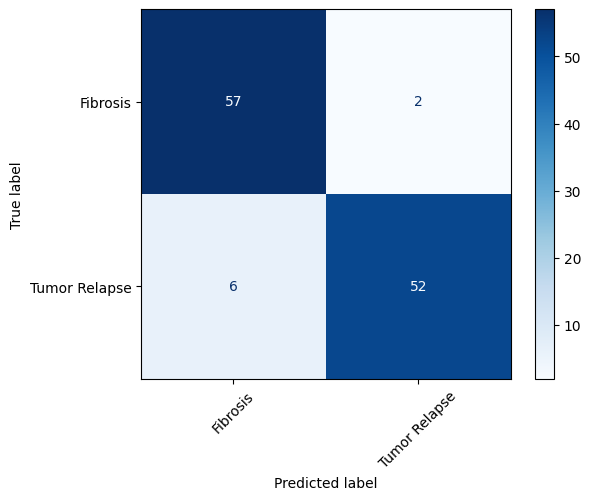

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import time
import torch

# Define class names
class_names = ["Fibrosis", "Tumor Relapse"]

# Start timing
start_time = time.time()

# Set model to evaluation mode
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels, suvs in val_loader:   # suvs ignored for ResNet9
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nInference Time on Validation Set: {elapsed_time:.2f} seconds")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)



ROC AUC score: 0.9661


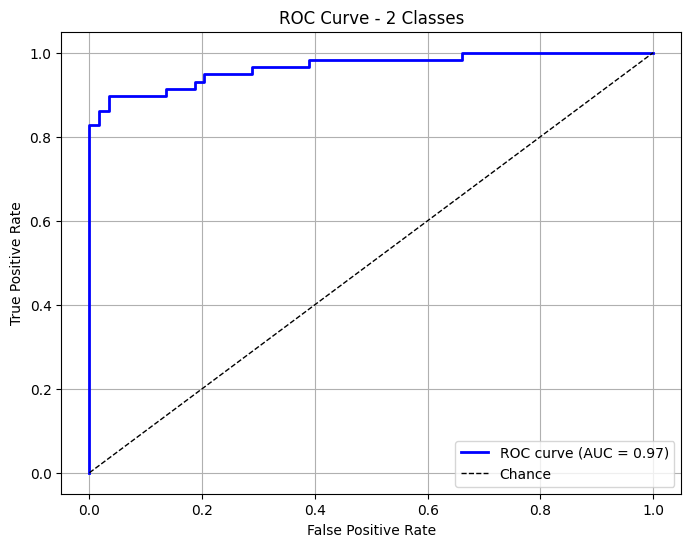

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get prediction probabilities for the positive class (class 1)
y_true = np.array(all_labels)
y_scores = []

model.eval()
with torch.no_grad():
    for images, labels, suvs in val_loader:  # suvs ignored for ResNet9
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities
        y_scores.extend(probs[:, 1].cpu().numpy())  # probability of class 1 (Tumor)

y_scores = np.array(y_scores)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Micro/Macro are same for 2-class
print(f"\nROC AUC score: {roc_auc:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='k', lw=1, linestyle='--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 2 Classes")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
from transformers import ViTConfig, ViTForImageClassification
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

# -------------------------------
# Device
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# ViT Configuration for 3-channel input
# -------------------------------
custom_vit_config = ViTConfig(
    image_size=224,
    patch_size=16,
    num_channels=3,  # RGB
    num_labels=2,    # Fibrosis vs Tumor
    hidden_size=96,
    num_hidden_layers=3,
    num_attention_heads=2,
    intermediate_size=512,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)

# -------------------------------
# Create ViT Model
# -------------------------------
vit_model = ViTForImageClassification(config=custom_vit_config)
vit_model.to(device)
print(vit_model)  # Print model structure

# -------------------------------
# Focal Loss
# -------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

criterion = FocalLoss(alpha=1.0, gamma=2.0)
optimizer = torch.optim.Adam(vit_model.parameters(), lr=1e-4)

# -------------------------------
# Training & Validation Parameters
# -------------------------------
num_epochs = 10
patience = 3  # Early stopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

# -------------------------------
# Training Loop
# -------------------------------
for epoch in range(num_epochs):
    if early_stop:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

    # ----- TRAINING -----
    vit_model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels, suvs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vit_model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # ----- VALIDATION -----
    vit_model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels, suvs in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            images, labels = images.to(device), labels.to(device)
            outputs = vit_model(images).logits
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val

    # ----- LOGGING -----
    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   Accuracy: {val_acc:.2f}%\n")

    # ----- EARLY STOPPING -----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_state = vit_model.state_dict()  # Save best model
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stop = True

# ----- LOAD BEST MODEL -----
vit_model.load_state_dict(best_model_state)
print("Loaded best model based on validation loss.")

# ----- CHECK ONE BATCH OUTPUT -----
images, labels, suvs = next(iter(val_loader))
images = images.to(device)
with torch.no_grad():
    outputs = vit_model(images).logits
print("Sample batch output shape:", outputs.shape)  # [batch_size, 2]


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-2): 3 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=96, out_features=96, bias=True)
              (key): Linear(in_features=96, out_features=96, bias=True)
              (value): Linear(in_features=96, out_features=96, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=96, out_features=96, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=96, out_features=512, bias=True)
            (intermediate_act_fn):

Epoch 1/10 [Validation]: 100%|██████████| 30/30 [00:01<00:00, 20.56it/s]



Epoch 1/10 Summary:
Train Loss: 0.0993 | Train Accuracy: 85.99%
Val   Loss: 0.1201 | Val   Accuracy: 77.78%



Epoch 2/10 [Validation]: 100%|██████████| 30/30 [00:00<00:00, 35.88it/s]



Epoch 2/10 Summary:
Train Loss: 0.0846 | Train Accuracy: 85.13%
Val   Loss: 0.0907 | Val   Accuracy: 84.62%



...

Epoch 5/10 [Validation]: 100%|██████████| 30/30 [00:00<00:00, 35.42it/s]



Epoch 5/10 Summary:
Train Loss: 0.0753 | Train Accuracy: 88.36%
Val   Loss: 0.0738 | Val   Accuracy: 88.89%



Epoch 6/10 [Validation]: 100%|██████████| 30/30 [00:00<00:00, 37.37it/s]


Epoch 6/10 Summary:
Train Loss: 0.0718 | Train Accuracy: 87.50%
Val   Loss: 0.0727 | Val   Accuracy: 88.03%


Early stopping triggered at epoch 6.
Loaded best model based on validation loss.


Sample batch output shape: torch.Size([4, 2])


Evaluation: 100%|██████████| 30/30 [00:00<00:00, 36.03it/s]


Classification Report:
               precision    recall  f1-score   support

     Fibrosis     0.8730    0.9322    0.9016        59
Tumor Relapse     0.9259    0.8621    0.8929        58

     accuracy                         0.8974       117
    macro avg     0.8995    0.8971    0.8972       117
 weighted avg     0.8992    0.8974    0.8973       117



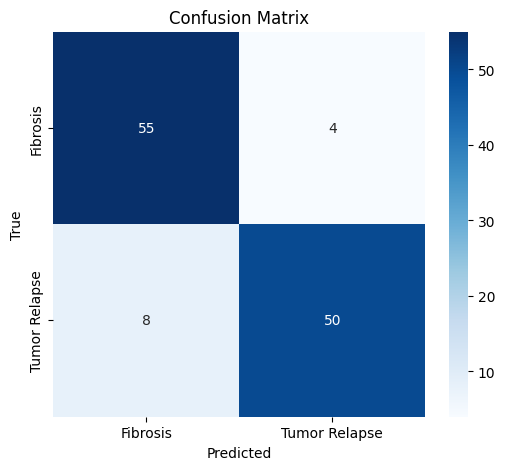

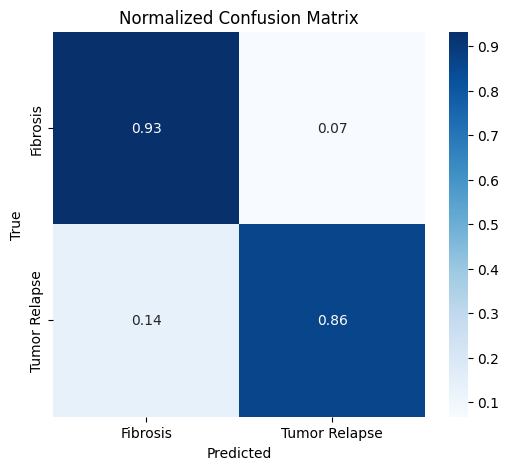

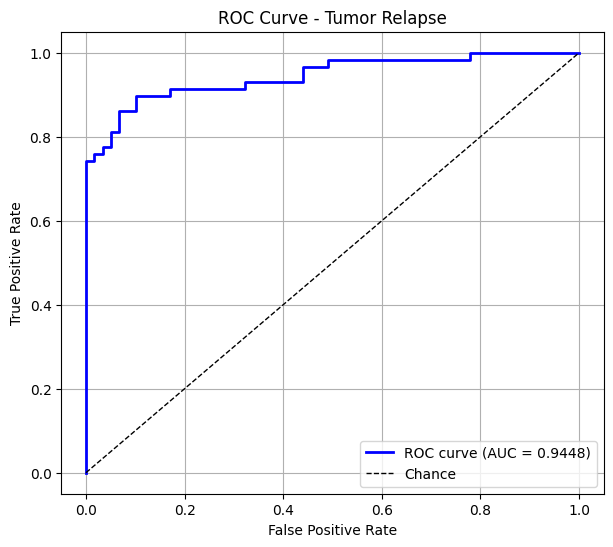

ROC AUC Score: 0.9448


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from tqdm import tqdm

# ----- Prepare lists -----
all_preds = []
all_probs = []
all_targets = []

vit_model.eval()
with torch.no_grad():
    for images, labels, suvs in tqdm(val_loader, desc="Evaluation"):  # 3 items
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images).logits  # [B, 2] or [B, 1]

        # Handle single-logit output (some ViT configs)
        if outputs.shape[1] == 1:
            probs = torch.sigmoid(outputs)              # [B, 1]
            probs = torch.cat([1-probs, probs], dim=1)  # [B, 2] -> class 0 & 1
        else:
            probs = torch.softmax(outputs, dim=1)       # [B, 2]

        _, preds = torch.max(probs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # positive class probability
        all_targets.extend(labels.cpu().numpy())

# Convert to NumPy arrays
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_targets = np.array(all_targets)

# ----- Classification Report -----
class_names = ['Fibrosis', 'Tumor Relapse']
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# ----- Confusion Matrix -----
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ----- Normalized Confusion Matrix -----
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ----- ROC Curve & AUC -----
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)
roc_auc_score_val = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_score_val:.4f})')
plt.plot([0, 1], [0, 1], color='k', lw=1, linestyle='--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tumor Relapse")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {roc_auc_score_val:.4f}")


ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.7953]], device='cuda:0')


Epoch 1/10 [Training]:   2%|▏         | 1/58 [00:00<00:06,  8.89it/s]

ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[1843.6171],
        [1356.1323],
        [3177.4595],
        [6388.0479],
        [6704.8237]], device='cuda:0')
ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[ 897.0278],
        [1334.6185],
        [1819.6310],
        [8938.8955],
        [8528.0439]], device='cuda:0')


Epoch 1/10 [Training]:   7%|▋         | 4/58 [00:00<00:05,  9.80it/s]

ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[1010.3658],
        [1252.8993],
        [2426.5266],
        [3144.2034],
        [1738.2314]], device='cuda:0')
ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[7329.1045],
        [3229.5530],
        [1304.8328],
        [1606.6368],
        [8067.1973]], device='cuda:0')
ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[1473.7845],
        [1368.8169],
        [ 947.4512],
        [1764.9446],
        [4236.8682]], device='cuda:0')


...

ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[1368.4092],
        [8054.9956],
        [1425.4216],
        [7176.2871],
        [4519.3159]], device='cuda:0')
ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[ 3008.9199],
        [13422.7334],
        [ 2487.0847],
        [ 1005.3458],
        [ 1698.5948]], device='cuda:0')


Epoch 6/10 [Validation]:  93%|█████████▎| 14/15 [00:01<00:00, 12.65it/s]

ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[ 1211.3954],
        [10563.7109],
        [ 1704.9106],
        [ 1352.9585],
        [ 1625.8157]], device='cuda:0')


Epoch 6/10 [Validation]: 100%|██████████| 15/15 [00:01<00:00, 13.15it/s]

ResNet feat shape: torch.Size([5, 512])
ViT feat shape: torch.Size([5, 96])
SUV shape: torch.Size([5, 1])
Fused shape: torch.Size([5, 609])
SUV values (first 5): tensor([[2563.8315],
        [1488.5530],
        [1771.5703],
        [8800.9531],
        [1152.2867]], device='cuda:0')

Epoch 6/10 Summary:
Train Loss: 2.1459 | Train Acc: 86.64%
Val   Loss: 0.2872 | Val   Acc: 94.87%

Early stopping triggered at epoch 6.
Loaded best model based on validation loss.

Classification Report:
              precision    recall  f1-score   support

    Fibrosis     0.9206    0.9831    0.9508        59
       Tumor     0.9815    0.9138    0.9464        58

    accuracy                         0.9487       117
   macro avg     0.9511    0.9484    0.9486       117
weighted avg     0.9508    0.9487    0.9486       117



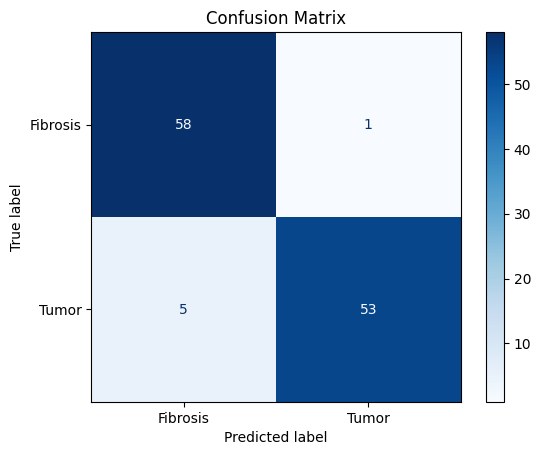

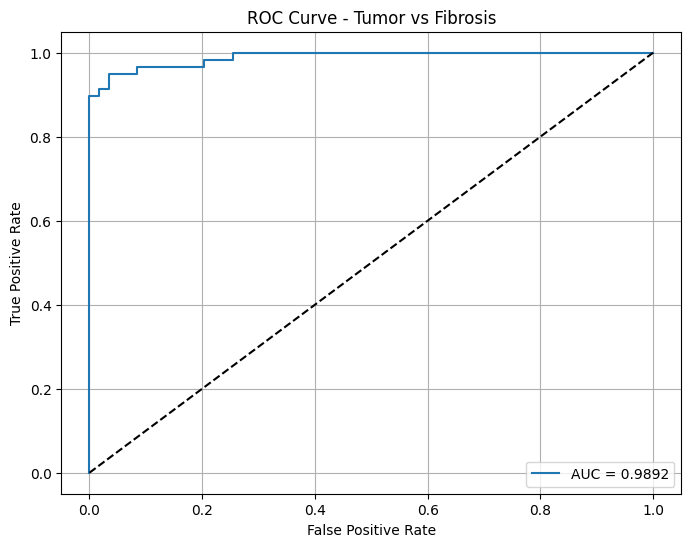

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from transformers import ViTConfig, ViTForImageClassification
from torchinfo import summary
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ----------------- Device -----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------- Focal Loss -----------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ----------------- Hybrid Model (Images + SUV) -----------------
# ----------------- Hybrid Model (Images + SUV) -----------------
class HybridResNetViT(nn.Module):
    def __init__(self, resnet_model, vit_model):
        super(HybridResNetViT, self).__init__()
        self.resnet_feature_extractor = nn.Sequential(*list(resnet_model.children())[:-1])  # Remove FC
        self.vit_feature_extractor = vit_model.vit  # ViT encoder

        # Classifier using MLP (including SUV)
        self.classifier = nn.Sequential(
            nn.Linear(512 + 96 + 1, 256),  # +1 for SUV input
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)  # 2 classes
        )

    def forward(self, x, suv):
        # ResNet features
        resnet_feat = self.resnet_feature_extractor(x)
        resnet_feat = resnet_feat.view(resnet_feat.size(0), -1)

        # ViT features
        vit_outputs = self.vit_feature_extractor(pixel_values=x)
        vit_feat = vit_outputs.last_hidden_state[:, 0, :]  # CLS token

        # Concatenate features with SUV
        suv = suv.view(-1,1)  # Ensure shape [B,1]

        # -------- Debug Prints --------
        print("ResNet feat shape:", resnet_feat.shape)
        print("ViT feat shape:", vit_feat.shape)
        print("SUV shape:", suv.shape)
        print("Fused shape:", torch.cat((resnet_feat, vit_feat, suv), dim=1).shape)
        print("SUV values (first 5):", suv[:5])
        # ------------------------------

        fused = torch.cat((resnet_feat, vit_feat, suv), dim=1)

        # Classifier
        out = self.classifier(fused)
        return out

# ----------------- Instantiate Models -----------------
resnet_model = models.resnet18(weights=None)
resnet_model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)

custom_vit_config = ViTConfig(
    image_size=224,
    patch_size=16,
    num_channels=3,
    num_labels=2,
    hidden_size=96,
    num_hidden_layers=3,
    num_attention_heads=2,
    intermediate_size=512,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)

vit_model = ViTForImageClassification(custom_vit_config)
hybrid_model = HybridResNetViT(resnet_model=resnet_model, vit_model=vit_model)
hybrid_model.to(device)

# ----------------- Model Summary -----------------
summary(hybrid_model, input_size=[(1,3,224,224),(1,1)])

# ----------------- Loss & Optimizer -----------------
criterion = FocalLoss(alpha=1.0, gamma=2.0)
optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=1e-4)

# ----------------- Training Settings -----------------
num_epochs = 10
patience = 3
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
class_names = ['Fibrosis', 'Tumor']

# ----------------- DataLoaders -----------------
# Assuming you have train_dataset and val_dataset ready using BreastPETDataset
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# ----------------- Training Loop -----------------
for epoch in range(num_epochs):
    hybrid_model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels, suvs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        images, labels, suvs = images.to(device), labels.to(device), suvs.to(device)

        optimizer.zero_grad()
        outputs = hybrid_model(images, suvs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # ----------------- Validation -----------------
    hybrid_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    all_preds, all_probs, all_targets = [], [], []

    with torch.no_grad():
        for images, labels, suvs in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            images, labels, suvs = images.to(device), labels.to(device), suvs.to(device)

            outputs = hybrid_model(images, suvs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val

    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    # ----------------- Early Stopping -----------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = hybrid_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

# ----------------- Load Best Model -----------------
if best_model_state:
    hybrid_model.load_state_dict(best_model_state)
    print("Loaded best model based on validation loss.")

# ----------------- Evaluation -----------------
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_targets = np.array(all_targets)

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

auc_score = roc_auc_score(all_targets, all_probs[:, 1])
fpr, tpr, _ = roc_curve(all_targets, all_probs[:, 1])

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tumor vs Fibrosis")
plt.legend()
plt.grid(True)
plt.show()


ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.9388]], device='cuda:0')


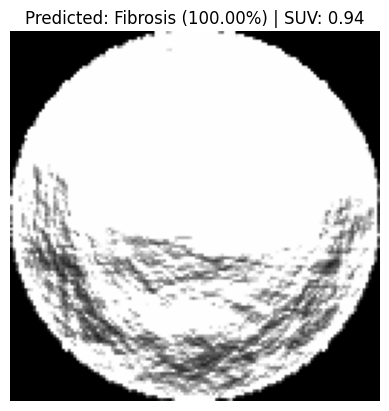

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.7818]], device='cuda:0')


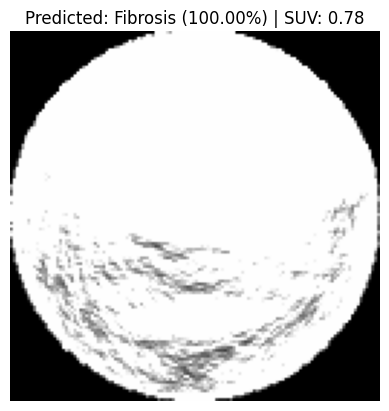

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.9305]], device='cuda:0')


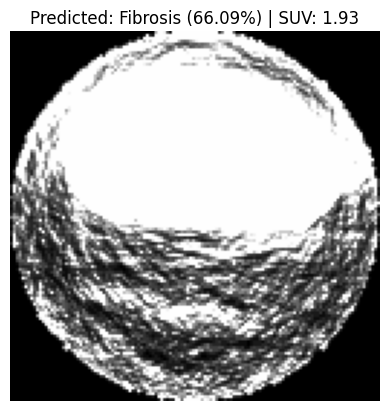

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.7725]], device='cuda:0')


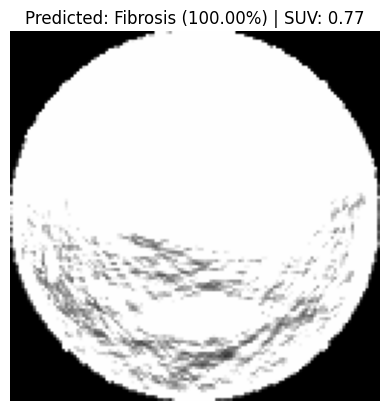

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.0371]], device='cuda:0')


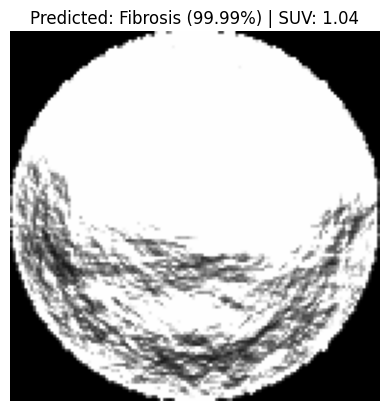

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.0305]], device='cuda:0')


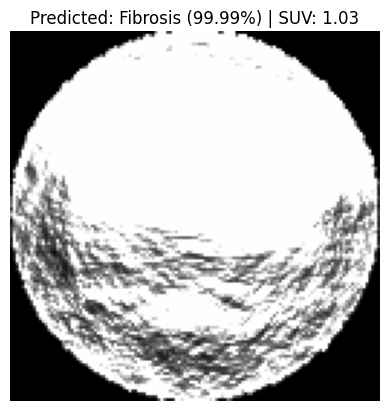

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.7653]], device='cuda:0')


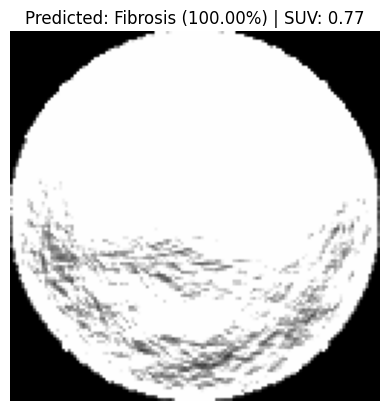

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.9173]], device='cuda:0')


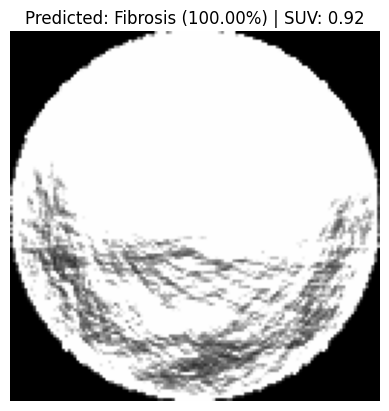

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.1859]], device='cuda:0')


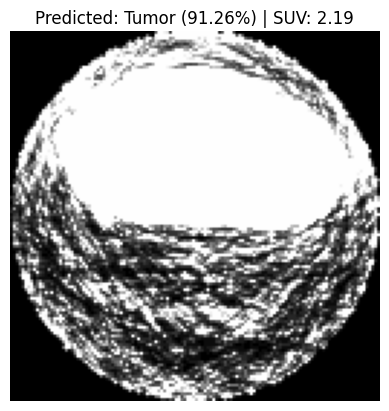

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[4.0696]], device='cuda:0')


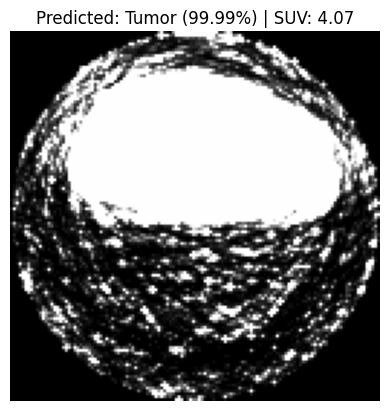

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2479]], device='cuda:0')


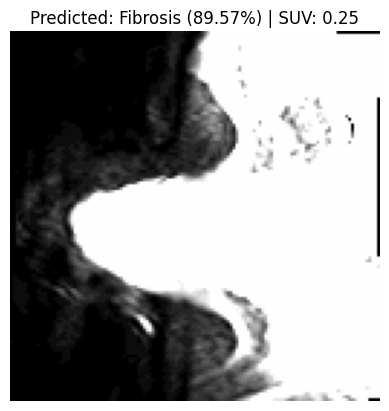

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2772]], device='cuda:0')


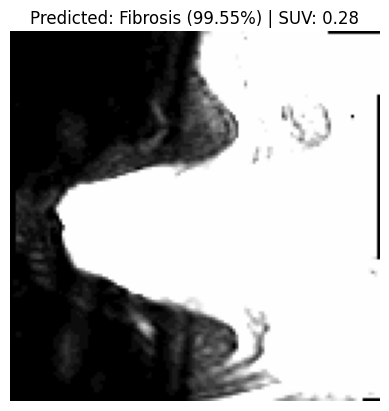

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2342]], device='cuda:0')


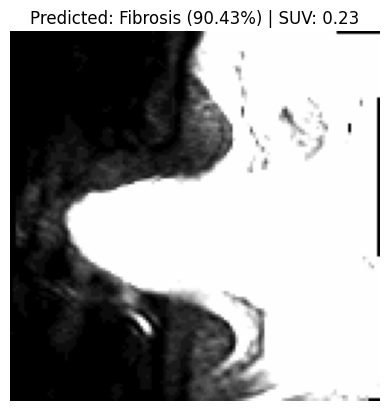

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2434]], device='cuda:0')


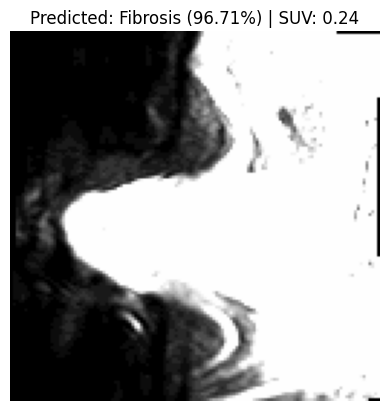

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2492]], device='cuda:0')


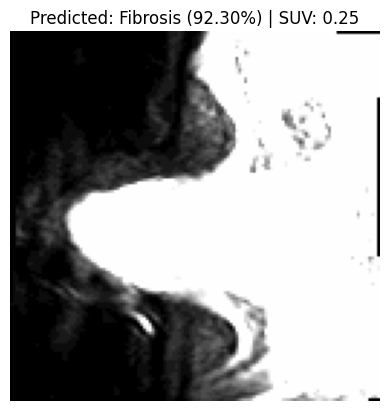

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2423]], device='cuda:0')


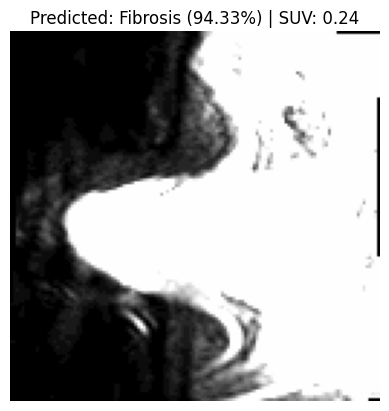

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.3828]], device='cuda:0')


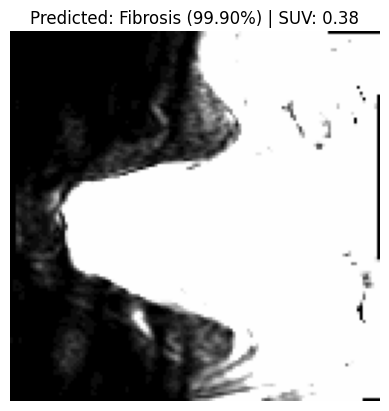

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2429]], device='cuda:0')


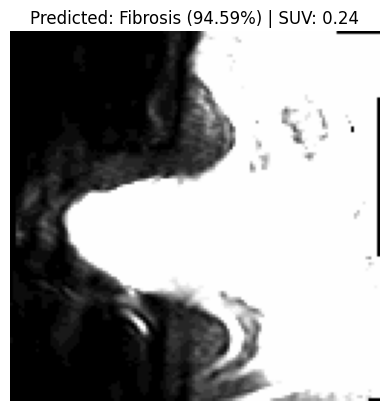

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2323]], device='cuda:0')


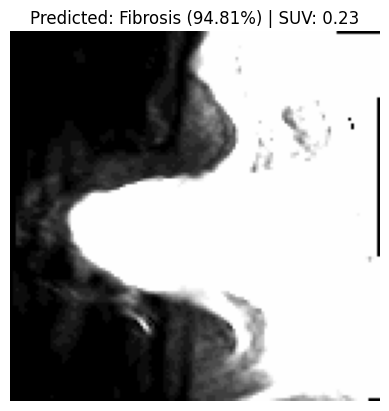

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.3382]], device='cuda:0')


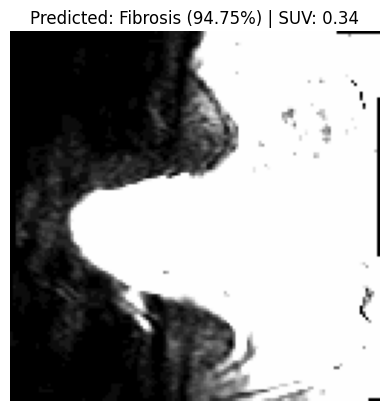

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7116]], device='cuda:0')


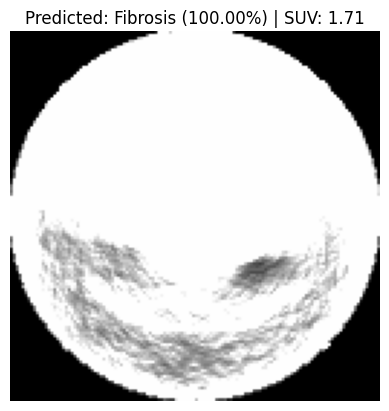

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.6145]], device='cuda:0')


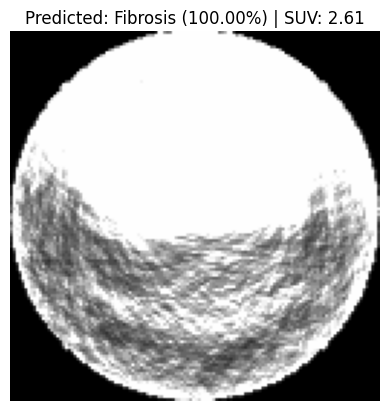

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.3618]], device='cuda:0')


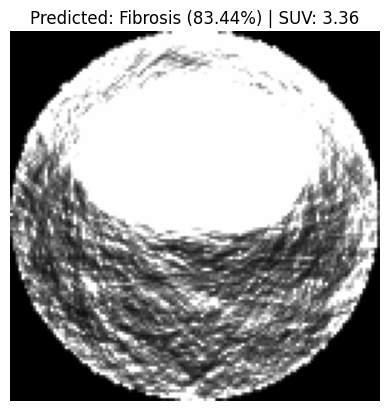

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.8468]], device='cuda:0')


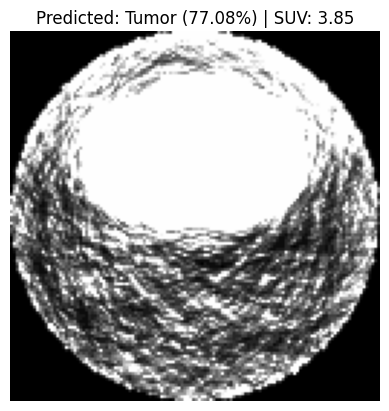

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[7.5497]], device='cuda:0')


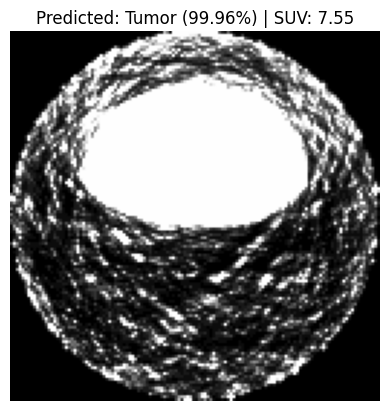

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.5756]], device='cuda:0')


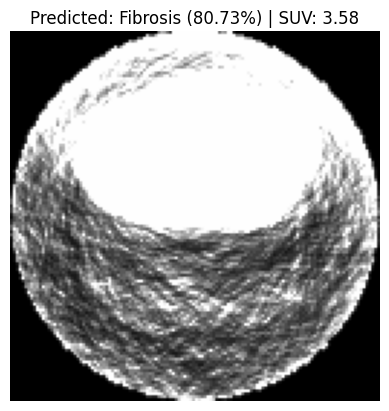

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7600]], device='cuda:0')


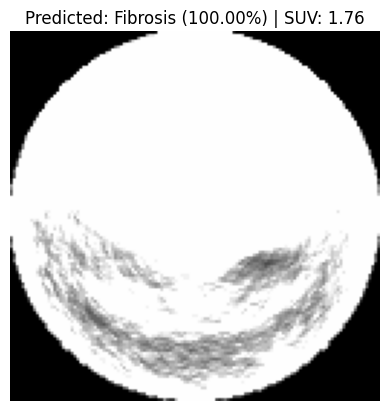

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.2832]], device='cuda:0')


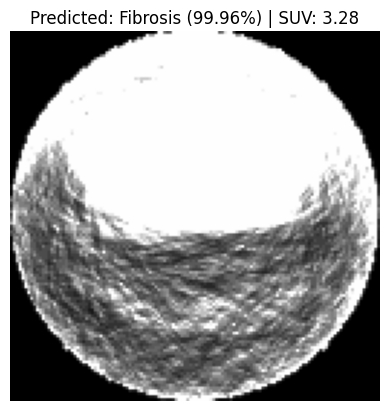

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.7100]], device='cuda:0')


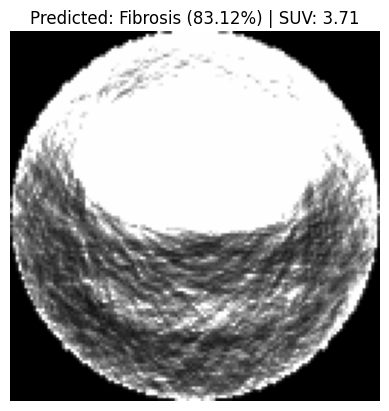

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.6055]], device='cuda:0')


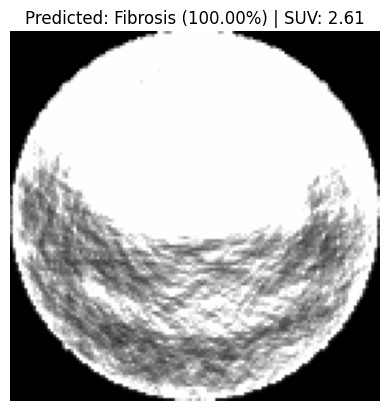

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7521]], device='cuda:0')


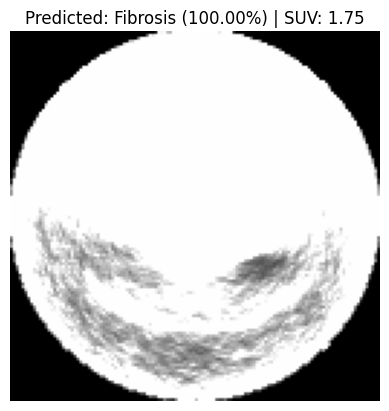

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.0436]], device='cuda:0')


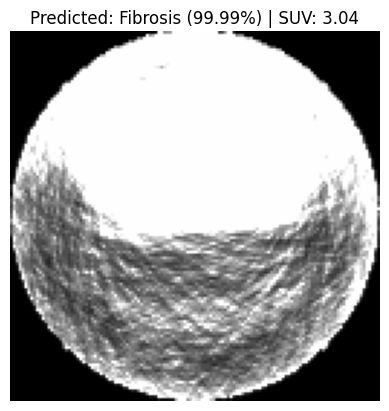

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.3552]], device='cuda:0')


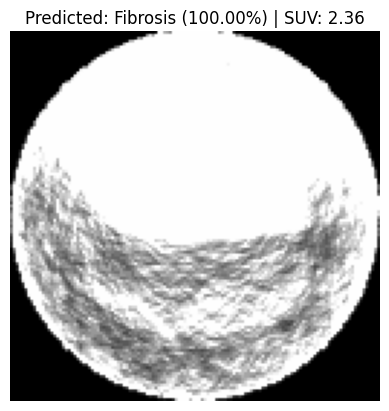

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7929]], device='cuda:0')


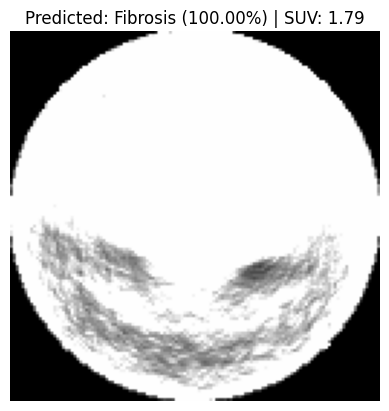

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.8080]], device='cuda:0')


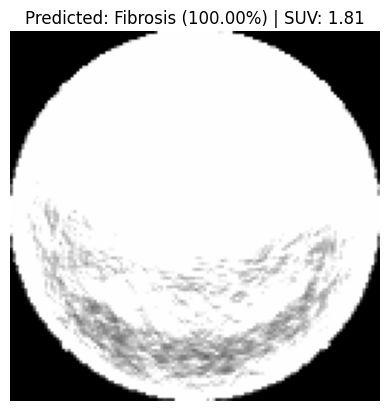

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.5492]], device='cuda:0')


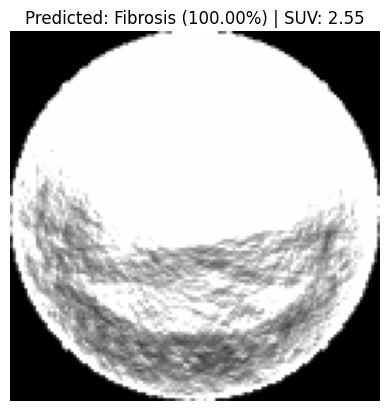

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.1552]], device='cuda:0')


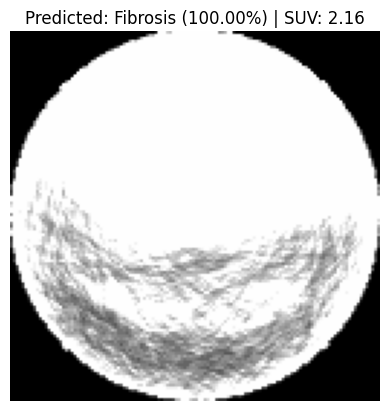

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.4198]], device='cuda:0')


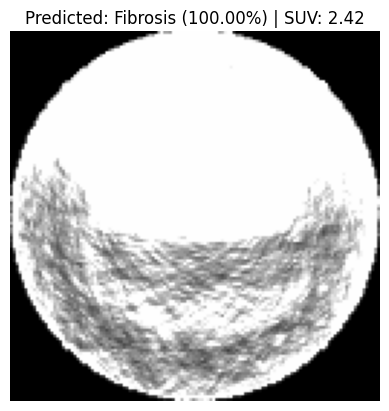

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.9148]], device='cuda:0')


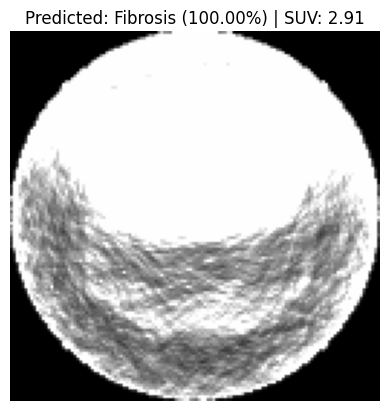

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.0375]], device='cuda:0')


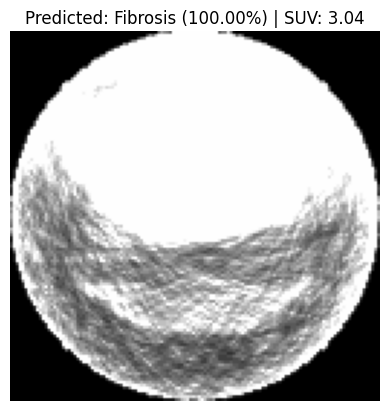

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.8602]], device='cuda:0')


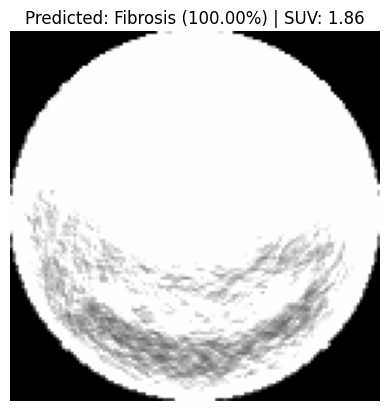

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.4894]], device='cuda:0')


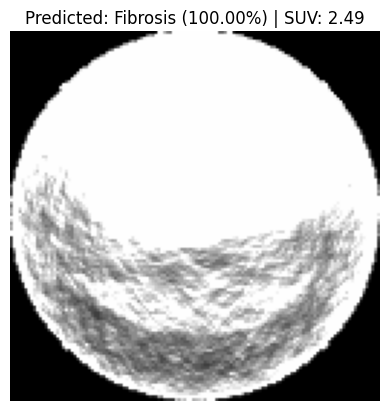

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.6924]], device='cuda:0')


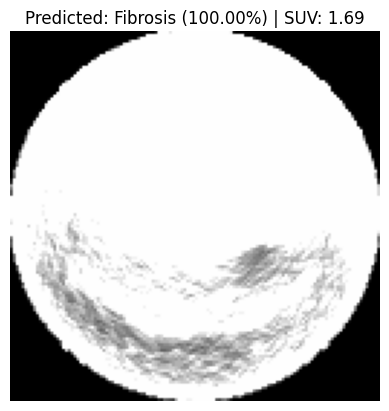

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7720]], device='cuda:0')


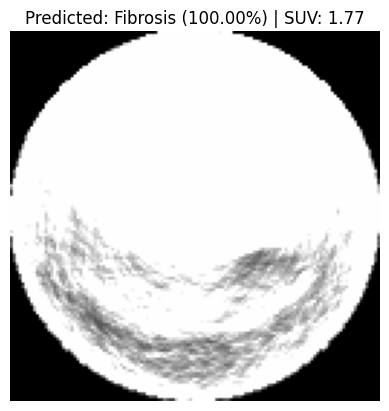

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.9997]], device='cuda:0')


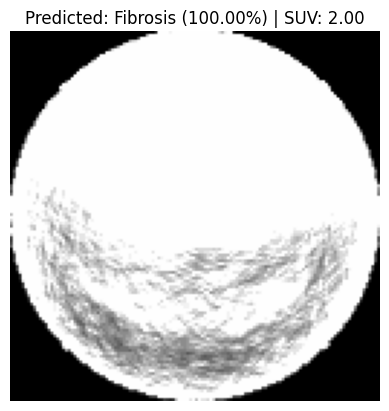

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7831]], device='cuda:0')


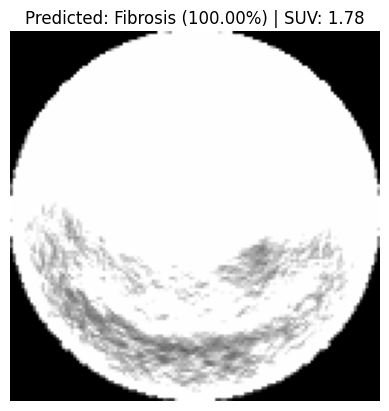

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.8051]], device='cuda:0')


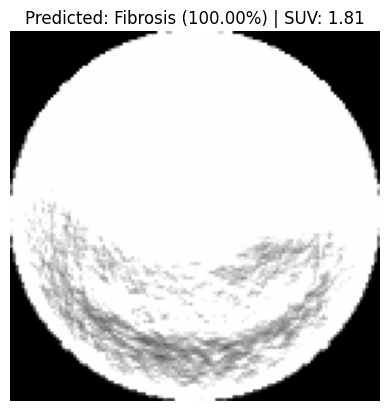

In [56]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import pydicom

# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hybrid_model.eval()  # Set model to evaluation mode

# ------------------- Image Folder -------------------
test_folder = "/content/drive/MyDrive/Major project Final models/test images"
image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith(".dcm")]

# ------------------- Preprocessing -------------------
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # standard ImageNet mean
                         std=[0.229, 0.224, 0.225])
])

# ------------------- Class Names -------------------
class_names = ['Fibrosis', 'Tumor']

# ------------------- DICOM → PIL Image -------------------
def dicom_to_pil(dicom_path):
    ds = pydicom.dcmread(dicom_path)
    img_array = ds.pixel_array.astype(np.float32)

    # Clip extreme PET values and normalize
    img_array = np.clip(img_array, 0, 20)
    img_array -= np.min(img_array)
    img_array /= (np.max(img_array) + 1e-5)
    img_array *= 255.0

    # Convert to 3-channel RGB
    img_array = np.stack([img_array]*3, axis=-1).astype(np.uint8)
    return Image.fromarray(img_array)

# ------------------- Inference & Display -------------------
for img_path in image_paths:
    # Load DICOM
    img = dicom_to_pil(img_path)
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    # Compute SUV
    dcm = pydicom.dcmread(img_path)
    suv_value = calculate_suv(dcm)  # your existing SUV function
    suv_tensor = torch.tensor([[suv_value]], dtype=torch.float32).to(device)

    # Model prediction
    with torch.no_grad():
        outputs = hybrid_model(input_tensor, suv_tensor)
        probs = F.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_class].item()

    # Display
    plt.imshow(np.array(img))
    plt.title(f"Predicted: {class_names[pred_class]} ({confidence*100:.2f}%) | SUV: {suv_value:.2f}")
    plt.axis('off')
    plt.show()
